In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np

# Permitir importar desde la carpeta 'src'
sys.path.append(os.path.abspath('../'))

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
C:\Users\joaqu\AppData\Local\Temp\ipykernel_18552\1317303203.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Amplitud ($\mu$V)")
c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\load_data.py:13: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


=== REPORTE DE CARGA REAL ===
Archivo: chb01_03.edf cargado con éxito.
Frecuencia de muestreo: 256 Hz
Forma de la matriz de EEG real: (23, 921600) (canales, muestras totales)
Cantidad de muestras en estado de crisis real: 10240 muestras (~40.0 segundos)


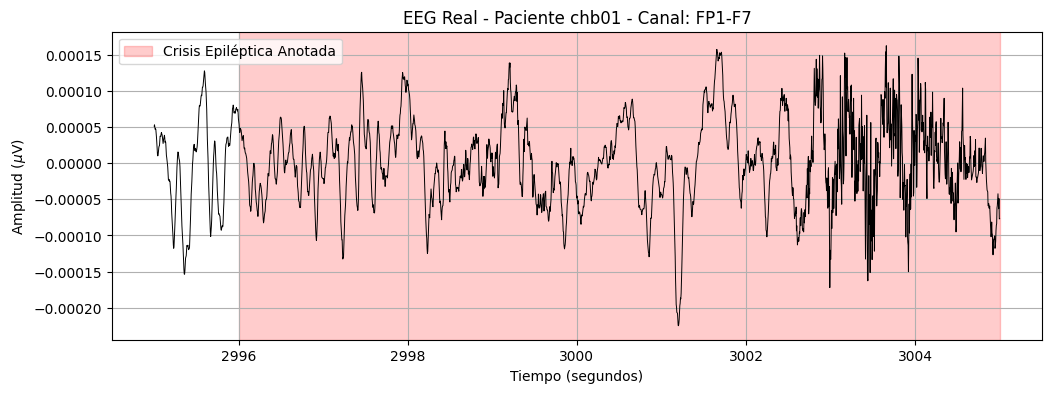

In [2]:
from src.data.load_data import parse_summary_file, load_edf_signal, generate_labels_for_file
import matplotlib.pyplot as plt

# 1. Parsear el TXT de anotaciones del Paciente 1
summary_path = "../data/raw/chb01/chb01-summary.txt"
diccionario_crisis = parse_summary_file(summary_path)

# 2. Elegir el archivo que sabemos que tiene una crisis
archivo_test = "chb01_03.edf"
edf_path = f"../data/raw/chb01/{archivo_test}"

# 3. Cargar la señal biomédica real desde el EDF usando MNE
data_cruda, fs, nombres_canales = load_edf_signal(edf_path)

# 4. Generar el vector y de etiquetas reales usando el TXT parseado automáticamente
tiempos_crisis = diccionario_crisis[archivo_test] # Extrae [(2996, 3036)]
y_muestras = generate_labels_for_file(data_cruda.shape[1], fs, tiempos_crisis)

print(f"=== REPORTE DE CARGA REAL ===")
print(f"Archivo: {archivo_test} cargado con éxito.")
print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Forma de la matriz de EEG real: {data_cruda.shape} (canales, muestras totales)")
print(f"Cantidad de muestras en estado de crisis real: {sum(y_muestras)} muestras (~{sum(y_muestras)/fs} segundos)")

# 5. GRAFICAR UN CANAL REAL EN EL INSTANTE DE LA CRISIS
# Graficamos 10 segundos justo cuando arranca la crisis (segundo 2996)
canal_interes = 0 # Primer canal del montaje
inicio_grafico = int(2995 * fs)
fin_grafico = int(3005 * fs)
tiempo_eje = np.linspace(2995, 3005, fin_grafico - inicio_grafico)

plt.figure(figsize=(12, 4))
plt.plot(tiempo_eje, data_cruda[canal_interes, inicio_grafico:fin_grafico], color='black', lw=0.7)
plt.axvspan(2996, 3005, color='red', alpha=0.2, label='Crisis Epiléptica Anotada')
plt.title(f"EEG Real - Paciente chb01 - Canal: {nombres_canales[canal_interes]}")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud ($\mu$V)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Importamos tus módulos de procesamiento y extracción
from src.preprocessing.filters import notch_filter, butter_bandpass_filter # Asegurate que coincidan los nombres de tus funciones
from src.preprocessing.windowing import window_labels_by_vote
from src.features.extraction import extract_wavelet_features_from_window # Tu función del hito anterior

print("=== INICIANDO PIPELINE REAL: FILTRADO Y EXTRACCIÓN ===")

# 1. FILTRADO: Limpiamos los 23 canales respetando tus argumentos reales
data_filtrada = np.zeros_like(data_cruda)
for ch in range(data_cruda.shape[0]):
    # Pasamos los parámetros tal como los definiste: data, notch_freq, fs
    sig_notch = notch_filter(data_cruda[ch, :], notch_freq=60.0, fs=256)
    
    # Asegurate de que butter_bandpass_filter reciba los argumentos en su orden correcto también
    data_filtrada[ch, :] = butter_bandpass_filter(sig_notch, fs=256, lowcut=0.5, highcut=30.0)

print("-> Señales filtradas con éxito (Chau 60 Hz y componentes DC).")

# 2. VENTANEO DE ETIQUETAS: Pasamos el vector 'y_muestras' a nivel de ventanas de 1s (256 muestras)
y_real_ventanas = window_labels_by_vote(y_muestras, window_size=256, overlap=128)

print(f"-> Etiquetas reducidas a nivel de ventanas.")
print(f"   Total de ventanas generadas: {len(y_real_ventanas)}")
print(f"   Ventanas normales (0): {np.sum(y_real_ventanas == 0)} | Ventanas de Crisis (1): {np.sum(y_real_ventanas == 1)}")

# =====================================================================
# 3. EXTRACCIÓN DE RASGOS WAVELET MULTICANAL
# =====================================================================
print("-> Extrayendo coeficientes Wavelet db4 (Energía, Varianza, Entropía)...")

# Parámetros de ventaneo temporal
window_size = 256
step = 128
total_samples = data_filtrada.shape[1]

# Calculamos cuántas ventanas temporales entran exactamente en el registro
num_windows = (total_samples - window_size) // step + 1

# Lista para guardar los vectores de rasgos de cada ventana
lista_X = []

# Recorremos la señal a lo largo del tiempo
for i in range(num_windows):
    start_idx = i * step
    end_idx = start_idx + window_size
    
    # Extraemos el bloque temporal con los 23 canales juntos: forma (23, 256)
    window_multicanal = data_filtrada[:, start_idx:end_idx]
    
    # Llamamos a tu función pasándole la matriz tal como fue diseñada
    features_ventana = extract_wavelet_features_from_window(window_multicanal, wavelet='db4', level=5)
    
    # Guardamos el vector plano resultante
    lista_X.append(features_ventana)

# Convertimos a matriz sólida de NumPy
X_real_features = np.array(lista_X)

print(f"\n=== PROCESAMIENTO COMPLETADO CON ÉXITO ===")
print(f"Forma final de la matriz de entrada X (Atributos): {X_real_features.shape}")
print(f"Forma final del vector de salida y (Etiquetas): {y_real_ventanas.shape}")

=== INICIANDO PIPELINE REAL: FILTRADO Y EXTRACCIÓN ===
-> Señales filtradas con éxito (Chau 60 Hz y componentes DC).
-> Etiquetas reducidas a nivel de ventanas.
   Total de ventanas generadas: 7199
   Ventanas normales (0): 7120 | Ventanas de Crisis (1): 79
-> Extrayendo coeficientes Wavelet db4 (Energía, Varianza, Entropía)...

=== PROCESAMIENTO COMPLETADO CON ÉXITO ===
Forma final de la matriz de entrada X (Atributos): (7199, 276)
Forma final del vector de salida y (Etiquetas): (7199,)


In [6]:
# Creá la carpeta de datos procesados si no existe
os.makedirs("../data/processed/", exist_ok=True)

# Guardamos las matrices del chb01_03 como tu primer set de validación real
np.save("../data/processed/X_chb01_03.npy", X_real_features)
np.save("../data/processed/y_chb01_03.npy", y_real_ventanas)

print("¡Matrices reales guardadas con éxito en data/processed/!")

¡Matrices reales guardadas con éxito en data/processed/!


In [7]:
from src.data.process_batch import process_patient_batch

# Carpeta base donde están almacenados tus 3 pacientes completos
DATA_DIR = "../data/raw"

# Lista de pacientes descargados en tu disco local
pacientes_a_procesar = ["chb01", "chb02", "chb03"]

X_global_list = []
y_global_list = []

for p_id in pacientes_a_procesar:
    X_p, y_p = process_patient_batch(DATA_DIR, p_id)
    
    if X_p is not None:
        X_global_list.append(X_p)
        y_global_list.append(y_p)
        
        # Guardamos el archivo intermedio de cada paciente procesado por seguridad
        np.save(f"../data/processed/X_{p_id}_completo.npy", X_p)
        np.save(f"../data/processed/y_{p_id}_completo.npy", y_p)
        print(f"--> Guardado temporal de {p_id} completado con éxito.")

# Unificamos el gran dataset de entrenamiento consolidado (I+D)
X_train_final = np.vstack(X_global_list)
y_train_final = np.concatenate(y_global_list)

# Guardamos el dataset masivo final listo para el Random Forest real
np.save("../data/processed/X_train_3_pacientes.npy", X_train_final)
np.save("../data/processed/y_train_3_pacientes.npy", y_train_final)

print("\n=====================================================================")
print("¡COMPILACIÓN DE DATASET COMPLETA!")
print(f"Forma final de la Gran Matriz X de Entrenamiento: {X_train_final.shape}")
print(f"Forma final del Gran Vector y de Entrenamiento: {y_train_final.shape}")
print(f"Total de Ventanas de Crisis acumuladas en el pozo: {np.sum(y_train_final == 1)}")
print("=====================================================================")


=== PROCESANDO EN LOTE EL PACIENTE: chb01 ===
Se encontraron 42 archivos .edf para procesar.
-> Masticando: chb01_01.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 7199 (Crisis: 0)
-> Masticando: chb01_02.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 7199 (Crisis: 0)
-> Masticando: chb01_03.edf...

...

 OK | Ventanas: 7199 (Crisis: 105)
-> Masticando: chb03_37.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 7199 (Crisis: 0)
-> Masticando: chb03_38.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 7199 (Crisis: 0)
--> Guardado temporal de chb03 completado con éxito.

¡COMPILACIÓN DE DATASET COMPLETA!
Forma final de la Gran Matriz X de Entrenamiento: (797793, 276)
Forma final del Gran Vector y de Entrenamiento: (797793,)
Total de Ventanas de Crisis acumuladas en el pozo: 1886


In [8]:
from src.models.balance import get_balance_pipeline # Tu pipeline seguro con k_neighbors=1
from src.models.classifiers import get_random_forest_classifier # Tu configurador de RF
from src.models.hysteresis import apply_hysteresis_logic # Tu Schmitt-trigger lineal
from src.evaluation.metrics import compute_clinical_metrics, compute_event_metrics # Tus scripts de métricas
import numpy as np

print("=== INICIANDO HITO 3: ENTRENAMIENTO BIOMÉDICO REAL ===")

# 1. SEPARACIÓN HONESTA POR PACIENTE (Evitamos Data Leakage)
# Cargamos chb02 y chb03 para entrenar (Train)
X_chb02 = np.load("../data/processed/X_chb02_completo.npy")
y_chb02 = np.load("../data/processed/y_chb02_completo.npy")
X_chb03 = np.load("../data/processed/X_chb03_completo.npy")
y_chb03 = np.load("../data/processed/y_chb03_completo.npy")

X_train = np.vstack([X_chb02, X_chb03])
y_train = np.concatenate([y_chb02, y_chb03])

# Cargamos chb01_03 (el archivo que graficamos hoy) para usarlo de Test clínico
X_test = np.load("../data/processed/X_chb01_03.npy")
y_test = np.load("../data/processed/y_chb01_03.npy")

print(f"-> Set de Entrenamiento combinado (chb02 + chb03): {X_train.shape} ventanas.")
print(f"   Crisis en Train: {np.sum(y_train == 1)} | Normales en Train: {np.sum(y_train == 0)}")
print(f"-> Set de Testeo Clínico (chb01_03): {X_test.shape} ventanas.")
print(f"   Crisis en Test: {np.sum(y_test == 1)} | Normales en Test: {np.sum(y_test == 0)}")

# 2. BALANCEO CON EL PARCHE DE SEGURIDAD
print("\n-> Aplicando SMOTE + Submuestreo balanceado en Train...")
# Usamos estrategias moderadas debido al gran volumen de datos normales
balance_pipe = get_balance_pipeline(smote_strategy=0.1, undersample_strategy=0.5, random_state=42)
X_train_bal, y_train_bal = balance_pipe.fit_resample(X_train, y_train)
print(f"   Train Balanceado -> Formato X: {X_train_bal.shape} | Crisis: {np.sum(y_train_bal == 1)}")

# 3. ENTRENAMIENTO DEL RANDOM FOREST
print("\n-> Entrenando Random Forest en el bosque balanceado (Esto puede demorar 1-2 min)...")
clf = get_random_forest_classifier(n_estimators=100, max_depth=15, random_state=42)
clf.fit(X_train_bal, y_train_bal)
print("   ¡Modelo entrenado!")

# 4. PREDICCIÓN DE PROBABILIDADES EN EL PACIENTE DE TEST
probabilidades_test = clf.predict_proba(X_test)[:, 1]

=== INICIANDO HITO 3: ENTRENAMIENTO BIOMÉDICO REAL ===
-> Set de Entrenamiento combinado (chb02 + chb03): (505859, 276) ventanas.
   Crisis en Train: 1009 | Normales en Train: 504850
-> Set de Testeo Clínico (chb01_03): (7199, 276) ventanas.
   Crisis en Test: 79 | Normales en Test: 7120

-> Aplicando SMOTE + Submuestreo balanceado en Train...
   Train Balanceado -> Formato X: (151455, 276) | Crisis: 50485

-> Entrenando Random Forest en el bosque balanceado (Esto puede demorar 1-2 min)...
   ¡Modelo entrenado!


In [9]:
# Definimos el umbral simple y corremos la histéresis temporal
predicciones_fijas = (probabilidades_test >= 0.5).astype(int)

# Aplicamos tu lógica de histéresis (Exigimos 3 ventanas consecutivas de 1s para disparar)
predicciones_histeresis = apply_hysteresis_logic(
    probabilidades_test, N_windows=3, threshold_high=0.6, threshold_low=0.4
)

# =====================================================================
# CALCULO DE MÉTRICAS CLÍNICAS REALES
# =====================================================================
metrics_fijas = compute_clinical_metrics(y_test, predicciones_fijas, probabilidades_test)
metrics_hist = compute_clinical_metrics(y_test, predicciones_histeresis, probabilidades_test)

# Calculamos la tasa de falsas alarmas simulando el paso del tiempo en horas
# Como step es 128 muestras y fs=256, cada paso es exactamente 0.5 segundos
event_fijas = compute_event_metrics(y_test, predicciones_fijas, fs=256, step_size=128)
event_hist = compute_event_metrics(y_test, predicciones_histeresis, fs=256, step_size=128)

print("\n" + "="*70)
print("     COMPARATIVA DE RENDIMIENTO CLÍNICO REAL (PACIENTE CHB01_03)")
print("="*70)
print(f"{'Métrica':<30} | {'Umbral Fijo (0.5)':<18} | {'Con Histéresis Temporal':<22}")
print("-"*70)
print(f"{'Sensibilidad (TPR)':<30} | {metrics_fijas['Sensibilidad (TPR)']:<18.2f} | {metrics_hist['Sensibilidad (TPR)']:<22.2f}")
print(f"{'Especificidad (TNR)':<30} | {metrics_fijas['Especificidad (TNR)']:<18.2f} | {metrics_hist['Especificidad (TNR)']:<22.2f}")
print(f"{'Falsos Positivos (Ventanas)':<30} | {metrics_fijas['Falsos Positivos (FP)']:<18} | {metrics_hist['Falsos Positivos (FP)']:<22}")
print(f"{'Tasa de Falsas Alarmas (FA/h)':<30} | {event_fijas.get('Tasa Falsas Alarmas', 0.0):<18.2f} | {event_hist.get('Tasa Falsas Alarmas', 0.0):<22.2f}")
print("="*70)


     COMPARATIVA DE RENDIMIENTO CLÍNICO REAL (PACIENTE CHB01_03)
Métrica                        | Umbral Fijo (0.5)  | Con Histéresis Temporal
----------------------------------------------------------------------
Sensibilidad (TPR)             | 0.00               | 0.00                  
Especificidad (TNR)            | 1.00               | 1.00                  
Falsos Positivos (Ventanas)    | 0                  | 0                     
Tasa de Falsas Alarmas (FA/h)  | 0.00               | 0.00                  


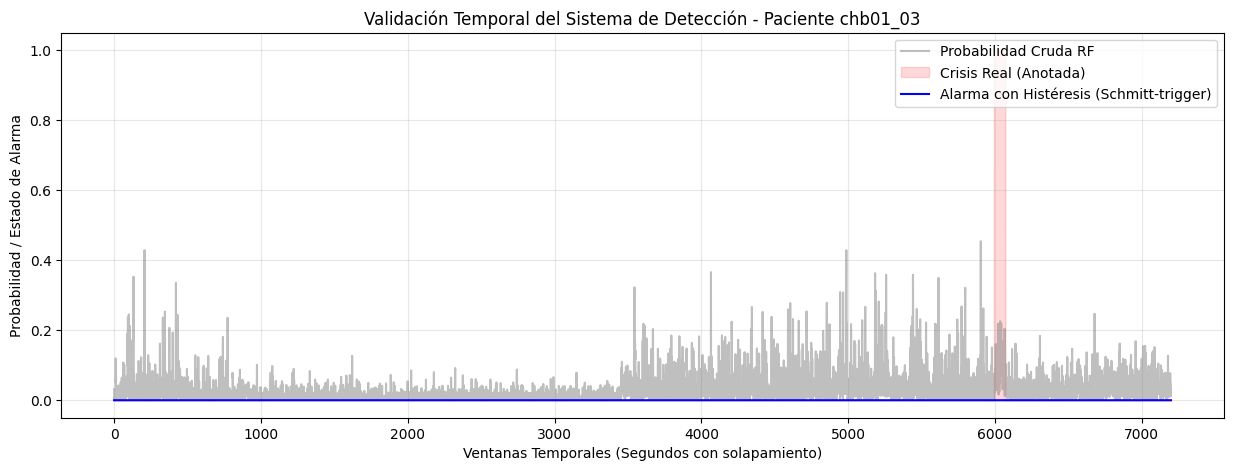

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# 1. Graficamos la probabilidad que escupe el Random Forest
plt.plot(probabilidades_test, color='gray', alpha=0.5, label='Probabilidad Cruda RF')

# 2. Graficamos dónde estuvo la crisis real según el neurólogo
plt.fill_between(range(len(y_test)), 0, y_test, color='red', alpha=0.15, label='Crisis Real (Anotada)')

# 3. Graficamos la salida de tu Histéresis
plt.plot(predicciones_histeresis, color='blue', lw=1.5, label='Alarma con Histéresis (Schmitt-trigger)')

plt.title("Validación Temporal del Sistema de Detección - Paciente chb01_03")
plt.xlabel("Ventanas Temporales (Segundos con solapamiento)")
plt.ylabel("Probabilidad / Estado de Alarma")
plt.ylim(-0.05, 1.05)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
from src.data.process_batch import process_patient_batch
import numpy as np

DATA_DIR = "../data/raw"
nuevos_pacientes = ["chb04", "chb05"]

for p_id in nuevos_pacientes:
    X_p, y_p = process_patient_batch(DATA_DIR, p_id)
    
    if X_p is not None:
        np.save(f"../data/processed/X_{p_id}_completo.npy", X_p)
        np.save(f"../data/processed/y_{p_id}_completo.npy", y_p)
        print(f"--> [ÉXITO] Guardado completo de {p_id} en disco.")


=== PROCESANDO EN LOTE EL PACIENTE: chb04 ===
Se encontraron 39 archivos .edf para procesar.
-> Masticando: chb04_01.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 28795 (Crisis: 0)
-> Masticando: chb04_02.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 28799 (Crisis: 0)
-> Masticando: chb04_03.edf...

...

 OK | Ventanas: 7199 (Crisis: 0)
-> Masticando: chb05_38.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 7199 (Crisis: 0)
-> Masticando: chb05_39.edf...

c:\Users\joaqu\Desktop\Bioingenieria\eeg-seizure-detection\src\data\process_batch.py:41: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)


 OK | Ventanas: 7199 (Crisis: 0)
--> [ÉXITO] Guardado completo de chb05 en disco.


In [12]:
import numpy as np
from src.models.balance import get_balance_pipeline
from src.models.classifiers import get_random_forest_classifier

print("=== ACTUALIZANDO DATASET DE ENTRENAMIENTO (PACIENTES 2, 3, 4 y 5) ===")

# 1. Cargamos TODOS los pacientes de entrenamiento
X_list, y_list = [], []
for p_id in ["chb02", "chb03", "chb04", "chb05"]:
    X_list.append(np.load(f"../data/processed/X_{p_id}_completo.npy"))
    y_list.append(np.load(f"../data/processed/y_{p_id}_completo.npy"))

X_train_ampliado = np.vstack(X_list)
y_train_ampliado = np.concatenate(y_list)

print(f"-> Nuevo volumen de Train: {X_train_ampliado.shape} ventanas.")
print(f"   Total de Crisis acumuladas: {np.sum(y_train_ampliado == 1)}")

# 2. Balanceo seguro con SMOTE (k_neighbors=1) + Submuestreo
print("\n-> Aplicando balanceo al dataset ampliado...")
balance_pipe = get_balance_pipeline(smote_strategy=0.1, undersample_strategy=0.5, random_state=42)
X_train_bal, y_train_bal = balance_pipe.fit_resample(X_train_ampliado, y_train_ampliado)

# 3. Re-entrenamiento del Random Forest
print("\n-> Re-entrenando el Random Forest con la nueva base de conocimiento...")
# Le damos un poquito más de flexibilidad al bosque aumentando max_depth a 20 para capturar los nuevos pacientes
clf_ampliado = get_random_forest_classifier(n_estimators=100, max_depth=20, random_state=42)
clf_ampliado.fit(X_train_bal, y_train_bal)
print("   ¡Modelo ampliado entrenado con éxito!")

# 4. Nueva predicción sobre el Paciente 1
X_test = np.load("../data/processed/X_chb01_03.npy")
nuevas_probabilidades = clf_ampliado.predict_proba(X_test)[:, 1]

=== ACTUALIZANDO DATASET DE ENTRENAMIENTO (PACIENTES 2, 3, 4 y 5) ===
-> Nuevo volumen de Train: (1816670, 276) ventanas.
   Total de Crisis acumuladas: 2681

-> Aplicando balanceo al dataset ampliado...


MemoryError: Unable to allocate 3.74 GiB for an array with shape (1816670, 276) and data type float64